In [131]:
import matplotlib.pyplot as plt
import numpy as np
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.datasets import california_housing
from keras import callbacks

(inputs, targets), (x_test, y_test) = california_housing.load_data(version='large', 
                                        test_split=0.2)
print(inputs.shape, targets.shape)
print(x_test.shape, y_test.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


In [132]:
# Split the data into training and validation sets (80% training, 20% validation)

split = int(len(inputs) * 0.8)

x_train = inputs[:split]
y_train = targets[:split]
x_val = inputs[split:]
y_val = targets[split:]

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

(13209, 8) (13209,)
(3303, 8) (3303,)


In [133]:
# Standardize input features

mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

x_train = (x_train - mean) / std
x_val = (x_val - mean) / std
x_test = (x_test - mean) / std

In [134]:
# First model with clearly overfitting setup

model = Sequential([
    Input(shape=(8,)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1)
])

model.summary()


model.compile(optimizer='adam',loss='mse',metrics=['mae'])

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_152 (Dense)               │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_153 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_154 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_155 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,961 (660.00 KB)

 Trainable params: 168,961 (660.00 KB)

 Non-trainable params: 0 (0.00 B)

In [135]:
# Train for 500 epochs for clear visual of overfitting

history = model.fit(x_train, y_train, epochs=500, batch_size=32, validation_data=(x_val, y_val), verbose=0)

As seen from the plot, the model starts to overfit at around 100 epochs.

Text(0, 0.5, 'Loss')

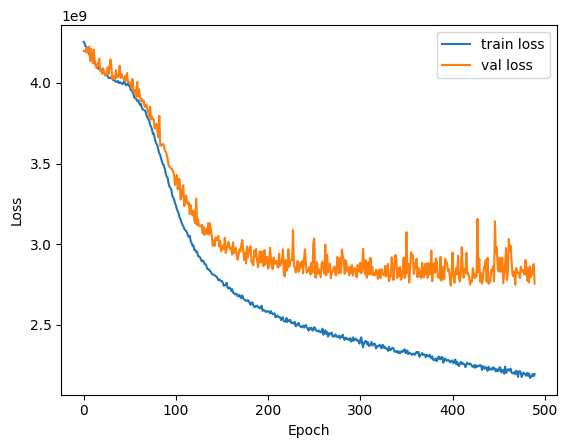

In [136]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

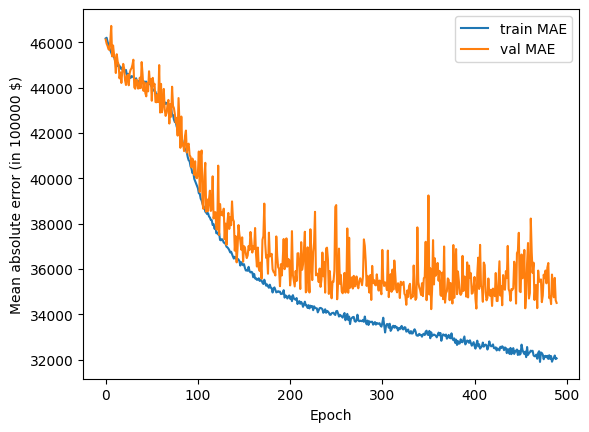

In [137]:
plt.plot(history.history['mae'][10:], label='train MAE')
plt.plot(history.history['val_mae'][10:], label='val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

Next we add early stop callback function, that monitors validation loss and stops the training when the model starts to overfit.
Also we add 10 % dropouts between dense layers to regularize the model and also prevent overfitting.

In [138]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [139]:
from keras.layers import Dropout

x_train_full = np.concatenate((x_train, x_val), axis=0)
y_train_full = np.concatenate((y_train, y_val), axis=0)

model2 = Sequential([
    Input(shape=(8,)),
    Dense(512, activation='relu'),
    Dropout(0.1),
    Dense(256, activation='relu'),
    Dropout(0.1),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

model2.compile(optimizer='adam',loss='mse',metrics=['mae'])
model2_history = model2.fit(x_train_full, y_train_full, epochs=500, batch_size=32, validation_split=0.2, verbose=0, callbacks=[early_stopping])



Training on the second model runs for ~90 epochs and as seen from the plot, it's not overfitting anymore.

Text(0, 0.5, 'Loss')

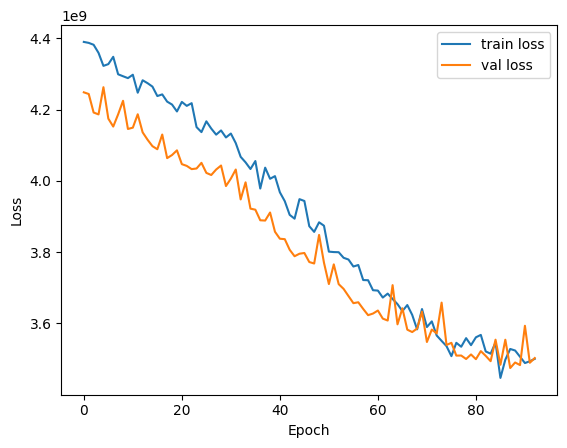

In [140]:
plt.plot(model2_history.history['loss'][10:], label='train loss')
plt.plot(model2_history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

As seen from the evaluation, the first model seems to have better MAE on paper, but it was heavily overfitting for ~400 epochs so the results are not reliable.
Second model that did not overfit has more realiable results with ~41 k/USD MAE, which indicates that it still learned a lot when comparing to the ~90 k/USD mean baseline MAE.

In [141]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error model 1: {test_mae:.4f}')

test_loss2, test_mae2 = model2.evaluate(x_test, y_test)
print(f'Test mean absolute error model 2: {test_mae2:.4f}')


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2809752832.0000 - mae: 34823.6328
Test mean absolute error model 1: 34509.0273
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3645142016.0000 - mae: 42240.0625
Test mean absolute error model 2: 41351.2969


In [142]:
from keras.losses import MeanAbsoluteError

y_pred_baseline = np.full_like(y_test, np.mean(y_train_full, axis=0))
mae_fn = MeanAbsoluteError()
mae_baseline = mae_fn(y_test, y_pred_baseline).numpy()
print(f'Mean baseline MAE: {mae_baseline:.4f}')


Mean baseline MAE: 90589.5000
